Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded embeddings: (48799, 384)
Loaded metadata:   48799 papers

Variance explained: PC1=6.5%, PC2=5.3%


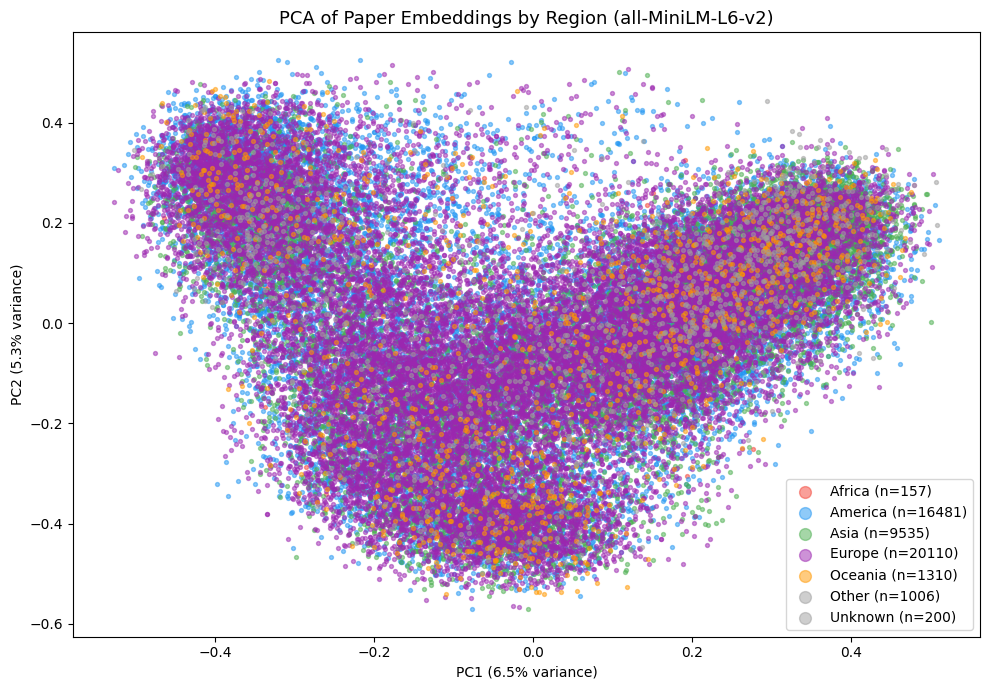


Saved → /content/drive/MyDrive/arxiv-rag-project/results/pca_embeddings_by_region.png


In [21]:
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np, json

# ── Correct full Drive paths ──────────────────────────────────────────────
PROJECT_DIR = "/content/drive/MyDrive/arxiv-rag-project"
RESULTS_DIR = f"{PROJECT_DIR}/results"

OUTPUT_EMB  = f"{RESULTS_DIR}/embeddings_no_chunk.npy"
OUTPUT_META = f"{RESULTS_DIR}/embeddings_meta_no_chunk.json"

# ── Load embeddings + meta ────────────────────────────────────────────────
embeddings = np.load(OUTPUT_EMB)
with open(OUTPUT_META) as f:
    meta = json.load(f)

print(f"Loaded embeddings: {embeddings.shape}")
print(f"Loaded metadata:   {len(meta)} papers")

# ── PCA → 2D ─────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(embeddings)
print(f"\nVariance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")

# ── Color map by region ───────────────────────────────────────────────────
regions = [p.get("region") or "Unknown" for p in meta]
unique_regions = sorted(set(regions))
color_map = {
    "America":  "#2196F3",   # blue
    "Europe":   "#9C27B0",   # purple
    "Asia":     "#4CAF50",   # green
    "Oceania":  "#FF9800",   # orange
    "Africa":   "#F44336",   # red
    "Unknown":  "#9E9E9E"    # grey
}

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
for region in unique_regions:
    mask = [i for i, r in enumerate(regions) if r == region]
    ax.scatter(
        emb_2d[mask, 0], emb_2d[mask, 1],
        c=color_map.get(region, "#9E9E9E"),
        label=f"{region} (n={len(mask)})",
        alpha=0.5, s=8
    )

ax.set_title("PCA of Paper Embeddings by Region (all-MiniLM-L6-v2)", fontsize=13)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.legend(markerscale=3)
plt.tight_layout()

# ── Save to Drive ─────────────────────────────────────────────────────────
save_path = f"{RESULTS_DIR}/pca_embeddings_by_region.png"
plt.savefig(save_path, dpi=150)
plt.show()
print(f"\nSaved → {save_path}")

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# ── Pick 5 interesting papers manually ───────────────────────────────────
# Strategy: 2 similar NLP papers, 2 similar CV papers, 1 unrelated (math/theory)
# Find them by searching for good candidates first

sims_matrix = cosine_similarity(embeddings[:500], embeddings[:500])  # check first 500

# Print some papers to pick good examples
for i in range(20):
    p = meta[i]
    print(f"[{i}] {p['region']:<10} {p['title'][:70]}")

[0] America    AI-Assisted Pipeline for Dynamic Generation of Trustworthy Health Supp
[1] America    Emergence of Scaling in Random Networks
[2] America    SMOTE: Synthetic Minority Over-sampling Technique
[3] Oceania    featureCounts: an efficient general purpose program for assigning sequ
[4] America    Statistical mechanics of complex networks
[5] America    The Structure and Function of Complex Networks
[6] Europe     Deep learning in neural networks: An overview
[7] America    Minimap2: pairwise alignment for nucleotide sequences
[8] America    Community structure in social and biological networks
[9] America    Atomically Thin <mml:math xmlns:mml="http://www.w3.org/1998/Math/MathM
[10] Europe     Raman Spectrum of Graphene and Graphene Layers
[11] America    Finding and evaluating community structure in networks
[12] America    Observation of Gravitational Waves from a Binary Black Hole Merger
[13] Europe     Astropy: A community Python package for astronomy
[14] Europe     A sur

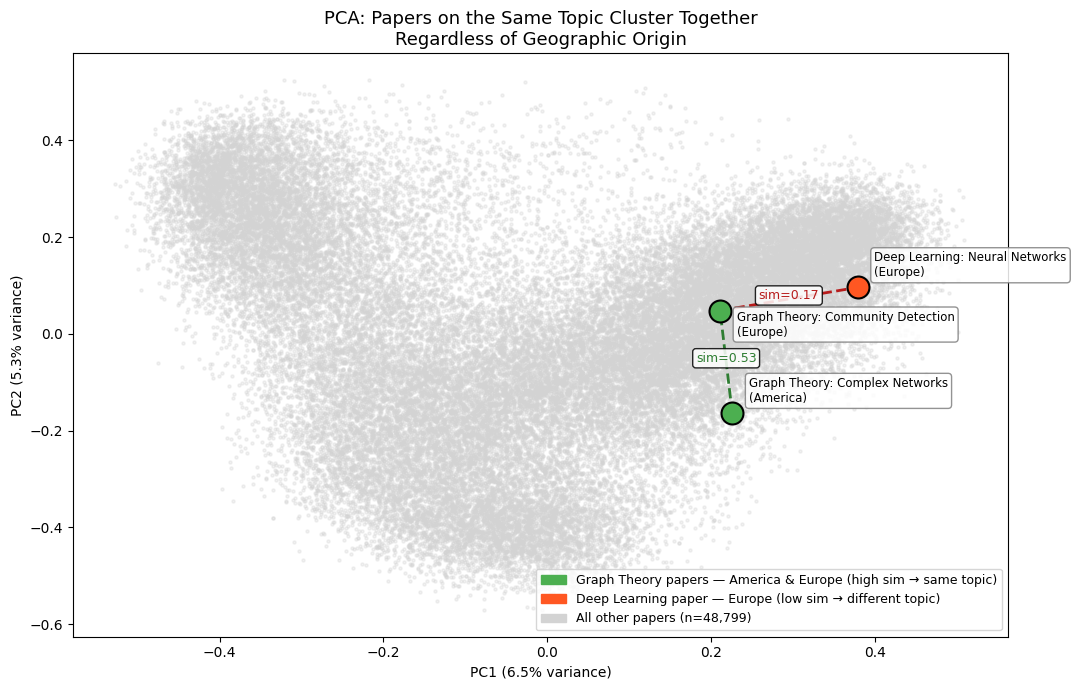

Saved → /content/drive/MyDrive/arxiv-rag-project/results/pca_3papers_highlighted.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

PROJECT_DIR = "/content/drive/MyDrive/arxiv-rag-project"
RESULTS_DIR = f"{PROJECT_DIR}/results"

# ── Selected 3 papers ─────────────────────────────────────────────────────
chosen = [4, 19, 6]
labels = [
    "Graph Theory: Complex Networks\n(America)",
    "Graph Theory: Community Detection\n(Europe)",
    "Deep Learning: Neural Networks\n(Europe)"
]
colors = ["#4CAF50", "#4CAF50", "#FF5722"]  # green=similar pair, red=dissimilar

# ── Get their 2D PCA positions ────────────────────────────────────────────
selected_2d = emb_2d[chosen]

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

# Background — all papers faded
ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c="lightgrey", s=5, alpha=0.3, zorder=1)

# Per-paper label offsets to avoid overlap
offsets = [(12, 8), (12, -18), (12, 8)]

for i, (x, y) in enumerate(selected_2d):
    ax.scatter(x, y, c=colors[i], s=250, zorder=3, edgecolors="black", linewidths=1.5)
    ax.annotate(
        labels[i],
        (x, y),
        textcoords="offset points",
        xytext=offsets[i],
        fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=0.85)
    )

# ── Helper to draw similarity lines ──────────────────────────────────────
def draw_line(ax, p1, p2, idx1, idx2, color):
    sim = cosine_similarity(
        embeddings[idx1].reshape(1, -1),
        embeddings[idx2].reshape(1, -1)
    )[0][0]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
            color=color, linewidth=2, linestyle="--", zorder=2)
    mid_x = (p1[0] + p2[0]) / 2
    mid_y = (p1[1] + p2[1]) / 2
    ax.annotate(
        f"sim={sim:.2f}",
        (mid_x, mid_y),
        fontsize=9,
        color=color,
        ha="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.85)
    )

# Similar pair (same topic, America vs Europe)
draw_line(ax, selected_2d[0], selected_2d[1], chosen[0], chosen[1], "#2E7D32")
# Dissimilar pair (different topic, both Europe)
draw_line(ax, selected_2d[1], selected_2d[2], chosen[1], chosen[2], "#B71C1C")

# ── Legend ────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(color="#4CAF50", label="Graph Theory papers — America & Europe (high sim → same topic)"),
    mpatches.Patch(color="#FF5722", label="Deep Learning paper — Europe (low sim → different topic)"),
    mpatches.Patch(color="lightgrey", label=f"All other papers (n={len(emb_2d):,})"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

ax.set_title(
    "PCA: Papers on the Same Topic Cluster Together\nRegardless of Geographic Origin",
    fontsize=13
)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()

save_path = f"{RESULTS_DIR}/pca_3papers_highlighted.png"
plt.savefig(save_path, dpi=150)
plt.show()
print(f"Saved → {save_path}")